# Testing for Scale-Free Properties in Networks

## Getting Started

Primary Research Question: Does the network exhibit scale-free properties (i.e., does the degree distribution follow a power law)?

We are basing this on the Clauset, Shalizi, and Newman's (2009) seminal paper, 'Power-Law Distributions in Empirical Data', for testing power law distributions in real-world data. 

First, load the tools of the trade:

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import powerlaw
import networkx as nx
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MultipleLocator

Read in the data:

In [5]:
# Load CSV with node degree attributes
df = pd.read_csv('data/edges_20260413.csv', encoding='utf-8', dtype=str)


G = nx.from_pandas_edgelist(
    df,
    source="source",
    target="target",
    create_using=nx.DiGraph,
)

print(
    "A network with {} nodes and {} edges.".format(G.number_of_nodes(), G.number_of_edges())
)

in_deg = dict(G.in_degree())
out_deg = dict(G.out_degree())
total_deg = dict(G.degree())  # in + out for DiGraph

degrees = pd.DataFrame({
    "node": list(G.nodes()),
    "in_degree": [in_deg[n] for n in G.nodes()],
    "out_degree": [out_deg[n] for n in G.nodes()],
    "total_degree": [total_deg[n] for n in G.nodes()],
})

# Extract degree values
degree_sequence = degrees['total_degree'].values

A network with 6675 nodes and 8017 edges.


Get some baseline measures:

In [44]:
def network_summary(G, weight="weight"):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    directed = G.is_directed()

    # --- Average degree ---
    avg_deg = sum(dict(G.degree()).values()) / n

    # --- Degree centralization (Freeman) ---
    # C = sum(d_max - d_i) / max_possible_sum
    # Undirected max = (n-1)(n-2); Directed in/out max = (n-1)^2
    degs = [d for _, d in G.degree()]
    d_max = max(degs)
    numer = sum(d_max - d for d in degs)
    denom = (n - 1) * (n - 2) if not directed else (n - 1) * (n - 1)
    centralization = numer / denom if denom > 0 else np.nan

    # --- Density ---
    density = nx.density(G)

    # --- Weak components (for directed); connected components if undirected ---
    if directed:
        n_components = nx.number_weakly_connected_components(G)
        largest = max(nx.weakly_connected_components(G), key=len)
    else:
        n_components = nx.number_connected_components(G)
        largest = max(nx.connected_components(G), key=len)
    H = G.subgraph(largest).copy()

    # --- Diameter & avg path length (on largest component, undirected view) ---
    # Directed diameter often infinite; standard practice is undirected projection
    H_und = H.to_undirected() if directed else H
    try:
        diameter = nx.diameter(H_und)
        avg_path_len = nx.average_shortest_path_length(H_und)
    except nx.NetworkXError:
        diameter = np.nan
        avg_path_len = np.nan

    # --- Average clustering coefficient ---
    # nx.average_clustering works on directed too, but undirected is the usual report
    avg_clustering = nx.average_clustering(G.to_undirected() if directed else G)

    return pd.DataFrame({
        "metric": [
            "Nodes",
            "Edges",
            "Average degree",
            "Degree centralization",
            "Density",
            "Weak components" if directed else "Connected components",
            "Diameter (largest comp.)",
            "Average clustering coefficient",
            "Average path length (largest comp.)",
        ],
        "value": [
            int(n),
            int(m),
            round(avg_deg, 4),
            round(centralization, 4),
            round(density, 4),
            n_components,
            diameter,
            round(avg_clustering, 4),
            round(avg_path_len, 4) if not np.isnan(avg_path_len) else "n/a",
        ],
    })

summary = network_summary(G, weight="weight")
print(summary.to_string(index=False))

                             metric     value
                              Nodes 6675.0000
                              Edges 8017.0000
                     Average degree    2.4021
              Degree centralization    0.1215
                            Density    0.0002
                    Weak components   60.0000
           Diameter (largest comp.)   20.0000
     Average clustering coefficient    0.0554
Average path length (largest comp.)    6.2237


Now we can get started with the work. We begin by exploring the data with a basic histogram. We are looking for a heavy tail.

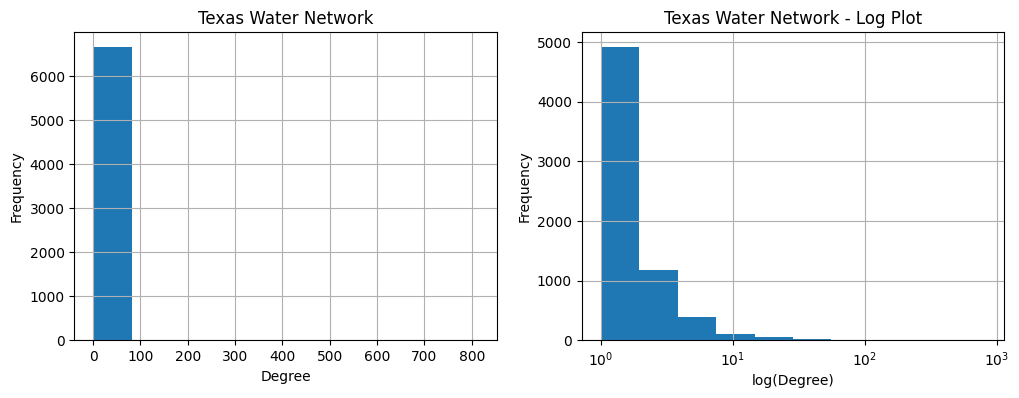

In [6]:
def plot_histograms(data: np.ndarray, title: str, var_name: str):
    """
    Plot side-by-side histograms:
    - Left: histogram of raw values
    - Right: histogram of log10(values) with ticks labeled as powers of 10

    Parameters
    - data: array-like of numeric values (zeros/non-positives are ignored for log plot)
    - title: main title shown for each subplot
    - var_name: variable name used for axis labels
    """
    plt.figure(figsize=(12, 4))

    # Linear histogram
    plt.subplot(1, 2, 1)
    plt.hist(data)
    plt.title(title)
    plt.xlabel(var_name)
    plt.ylabel("Frequency")
    plt.grid()

    # Log10 histogram (ignore non-positive values)
    positive = np.array(data)[np.array(data) > 0]
    plt.subplot(1, 2, 2)
    plt.hist(np.log10(positive))
    plt.title(title + " - Log Plot")
    plt.xlabel("log(" + var_name + ")")
    plt.ylabel("Frequency")
    plt.grid()

    # Use integer ticks for log10 bins and format as 10^{n}
    plt.gca().xaxis.set_major_locator(MultipleLocator(1))
    plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'10$^{{{int(x)}}}$'))

# Plot the histograms for the degree sequence
plot_histograms(degree_sequence, "Texas Water Network", "Degree")

The initial view of the data as histograms, particularly the log histogram, suggests that the distribution has the heavy-tail characteristic of a power law distribution.

Next, take a look at the data using the basic log-log plot, this is a quick way to visually "guess-timate" is the data follows a power law. That is, we should easily spot a heavy tail. This is **only** a useful tool for data exploration as it does not test if the data fit a power law distribution. 

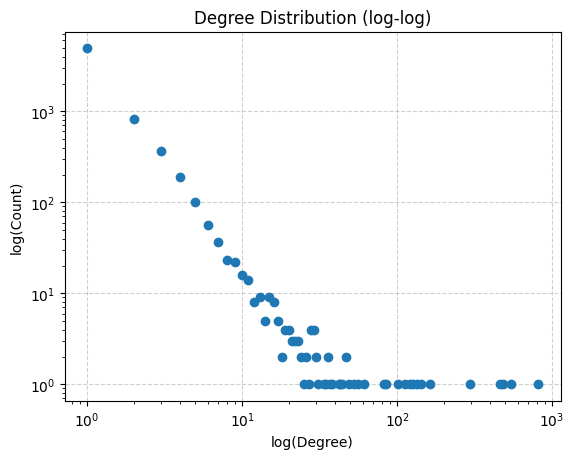

In [7]:
def plot_loglog_distribution(data: np.ndarray, title: str, var_name: str):
    """
    Plot the empirical discrete distribution on log-log axes.

    Parameters
    - data: 1D array-like of degree values (zeros and negatives are ignored)
    - title: plot title
    - var_name: variable name used for axis labels (e.g., "Degree")

    """

    # get unique degree values and their counts
    unique_vals, counts = np.unique(data, return_counts=True)

    plt.figure()
    plt.loglog(unique_vals, counts, marker='o', linestyle='None')
    plt.xlabel(f'log({var_name})')
    plt.ylabel('log(Count)')
    plt.title(title)
    plt.grid(linestyle='--', alpha=0.6)

# Plot the log-log distribution for the degree sequence
plot_loglog_distribution(degree_sequence, 'Degree Distribution (log-log)', 
    'Degree')

The log-log plot actually is pretty helpful in visually identifying potential power law scaling. The heavy tail distribution suggests the presence of hub nodes that dominate the network. However, it is not a perfect fit. That is, the curve flattens suggesting an exponential cutoff. That is, the network stops following the power law, this could be for a range of reasons (e.g., physical constraints).

The next step would be to plot a probability density function, which shows our data (empirical line) against a theoretical power law model. While this is still a visual assessment, it is helpful in making some high-level assessments:

- Lines overlap well at lower degrees but this agreement falls apart at higher degree values. This is consistent with what we saw with the log-log plot.
- This plot provides additional evidence that this network is "scale-free-ish" but with realistic constraints, which is typical for most real-world complex networks.

Degree data is discrete: True
Calculating best minimal value for power law fit


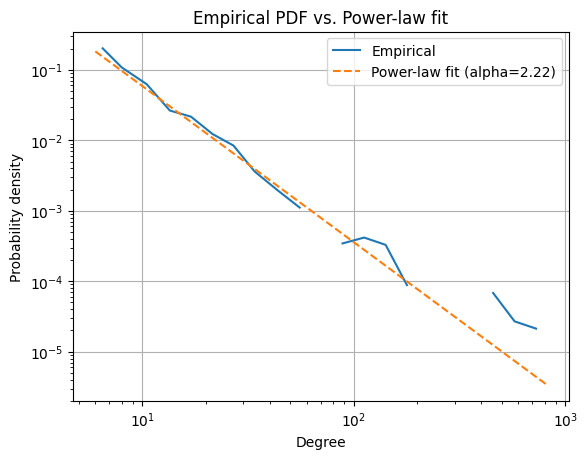

In [8]:
def plot_pdf(data: np.ndarray, discrete: bool = True):
    """
    Plot the empirical and fitted power-law probability density functions (PDFs).

    Behavior and assumptions:
    - Filters out non-positive values (power-law fits require positive support).
    - Uses discrete=True in powerlaw.Fit because degree data are integers.
    - Overlays the empirical PDF and the fitted power-law PDF, annotating the fit's alpha.

    Parameters
    - data: 1D numpy array of degree values (e.g., degree_sequence)
    - discrete: whether to treat data as discrete (default True for degree data)

    Returns
    - ax: matplotlib Axes containing the plot
    """
    # Keep only positive values (powerlaw library expects positive support)
    positive = np.array(data)[np.array(data) > 0]

    if positive.size == 0:
        raise ValueError("No positive values available for fitting.")

    # Fit the power-law model to the positive data
    fit = powerlaw.Fit(positive, discrete=discrete)

    # plot_pdf returns a matplotlib Axes; call it `ax` (not a figure)
    ax = fit.plot_pdf(label='Empirical', color='C0')

    # Overlay the fitted power-law PDF and label with the estimated alpha
    fit.power_law.plot_pdf(
        label=f'Power-law fit (alpha={fit.power_law.alpha:.2f})',
        linestyle='--',
        ax=ax,
        color='C1'
    )

    # Add labels, title, legend and grid for clarity
    ax.set_xlabel('Degree')
    ax.set_ylabel('Probability density')
    ax.set_title('Empirical PDF vs. Power-law fit')
    ax.legend()
    ax.grid(True)

# Call the documented plotting helper on the existing degree_sequence
dis = all(x == int(x) for x in degree_sequence)
print(f"Degree data is discrete: {dis}")
plot_pdf(degree_sequence, discrete=dis)


Next, perform a goodness-of-fit test to determine if your data actually follows a power law distribution. As discussed [here](https://projects.iq.harvard.edu/files/ac298r/files/power_law_distributions_in_empirical_data.pdf), "Given an observed data set and a hypothesized
power-law distribution from which the data are drawn, we would like to know whether our hypothesis is a plausible one, given the data.[...]
A standard approach to answering this kind of question is to use a goodness-of-fit test, which generates a p-value that quantifies the plausibility of the hypothesis. Such tests are based on measurement of the “distance” between the distribution of the
empirical data and the hypothesized model. This distance is compared with distance measurements for comparable synthetic data sets drawn from the same model, and the p-value is defined to be the fraction of the synthetic distances that are larger than the empirical distance. If p is large (close to 1), then the difference between the empirical data and the model can be attributed to statistical fluctuations alone; if it is small, the model is not a plausible fit to the data". 

This is to say, we use a goodness-of-fit test to to measure the distance between our real data and the fitted power-law model. This "distance" quantifies how well they match (there are various mathematical ways to measure this, like the Kolmogorov-Smirnov (KS) statistic). 

For our network the computed p-value is 0.98, which is very high. This suggests strong support for the power-law hypothesis. Specifically, we observe that only 2% of the synthetic power law datasets had a worse fit (larger KS statistic) than the empirical data. That is, our water network data fits the power law model well. However, this does not mean that we are out of the woods. To be clear, many other distributions could also fit the data well. In the next step, we compare whether other models might be a better alternative.

In [9]:
def compute_power_law_p_val(results):
    """
        Function to compute power law test p value as described in arXiv:0706.1062 [physics.data-an]

        Authors use rule of thumb significance threshold of p>=0.1

        Note: the larger the p value the more plausible a power law fit.
        The process is rather interesting, but is simplified by the powerlaw library. Essentially, the process is:
        1. Fit the power law model to the data and calculate the KS statistic (D_empirical)
        2. Generate many synthetic data sets from the fitted power law model
        3. For each synthetic data set, fit a power law model and calculate the KS statistic (D_synthetic)
        4. The p-value is the fraction of synthetic KS statistics that are larger than the empirical KS statistic:
            p-value = (number of D_synthetic ≥ D_empirical) / (total number of synthetic datasets)
    """

    return sum(results.Ds > results.D)/len(results.Ds)


# fit power to power law data
results = powerlaw.Fit(degree_sequence, discrete=dis)
print("alpha = " + str(results.power_law.alpha)) # note: powerlaw lib's alpha definition is different than standard i.e. a_powerlawlib = a_standard + 1
print("x_min = " + str(results.power_law.xmin))
print('p = ' + str(compute_power_law_p_val(results)))



Calculating best minimal value for power law fit
alpha = 2.2168045971216497
x_min = 6.0
p = 0.9824561403508771


This final step is to compare the power law fit to other potential distributions (e.g., exponential, log-normal, stretched exponential). This is done using a log likelihood ratio (R) test. The results are summarized in the table below:

In [10]:
def compare_distribution_fits(data: np.ndarray, discrete: bool = True) -> pd.DataFrame:
    """
        Function to compare power law fit to other distribution candidates

        Note:
        R = Log likelihood ratio of the two distributions’ fit to the data. If greater than 0, the first distribution is preferred. 
        If less than 0, the second distribution is preferred.

        p = Significance of R
    """

    distribution_list = ['lognormal', 'exponential', 'truncated_power_law', 
        'stretched_exponential', 'lognormal_positive']
    
    fit = powerlaw.Fit(data, discrete=discrete)

    rows = []
    for distribution in distribution_list:
        try:
            R, p = fit.distribution_compare('power_law', distribution)
        except Exception:
            R, p = np.nan, np.nan
        preferred = None
        if not np.isnan(R):
            preferred = 'power_law' if R > 0 else distribution
        rows.append({
            'base_distribution': 'power_law',
            'alt_distribution': distribution,
            'R': np.round(R, 3) if not np.isnan(R) else np.nan,
            'p': np.round(p, 3) if not np.isnan(p) else np.nan,
            'preferred': preferred
        })

    compare_df = (pd.DataFrame(rows)
                    .sort_values('R', ascending=False)
                    .reset_index(drop=True))
    return compare_df


# Compare distribution fits:
compare_distribution_fits(degree_sequence, discrete=dis)


Calculating best minimal value for power law fit


/Users/chris/Desktop/twn-first-paper/venv/lib/python3.11/site-packages/powerlaw.py:1570: RuntimeWarning: invalid value encountered in divide
  return likelihoods/norm
Assuming nested distributions


,base_distribution,alt_distribution,R,p,preferred
0,power_law,exponential,187.915,0.000,power_law
1,power_law,lognormal_positive,9.146,0.019,power_law
2,power_law,stretched_exponential,2.768,0.094,power_law
3,power_law,truncated_power_law,-0.009,0.896,truncated_power_law
4,power_law,lognormal,-6.520,0.313,lognormal


What does the output mean? Well here the R score indicates the direction of the fit, that is, whether the power law or the alternative distribution is preferred. A positive R value indicates that the power law is favored, while a negative R value suggests that the alternative distribution is a better fit. The p-value assesses the statistical significance of this preference. A low p-value (typically < 0.05) indicates that the observed preference is statistically significant and not due to random chance.

So how did our network do? Well, the power law was strongly favored over the Exponential and Lognormal (Positive) distributions, with positive R values and low p-values. The power law was weakly favored over the Stretched Exponential, with a positive R value and an insignificant p-value. Finally the Truncated Power Law and Lognormal was weakly favored over the power law, with a negative R values and an insignificant p-values.

## Parting Thoughts

Overall, we ran three checks:
1. Visual inspection (histograms, log-log plots, PDF plots)
2. Goodness-of-fit test
3. Comparison with alternative distributions

In all, the data shows evidence of a power-law distribution, but with some caveats. The visualizations and goodness-of-fit test support the power-law hypothesis, but the comparison with alternative distributions suggests that other models (like the truncated power law or lognormal) could also be plausible fits. This is common in real-world networks, which often exhibit scale-free properties but with realistic constraints that deviate from a pure power-law behavior.

However, we can rule out exponential distributions while maintaining a great fit. This provides sufficient evidence to suggest that the network is "scale-free-ish", which has important implications for understanding its structure and dynamics.


Calculating best minimal value for power law fit


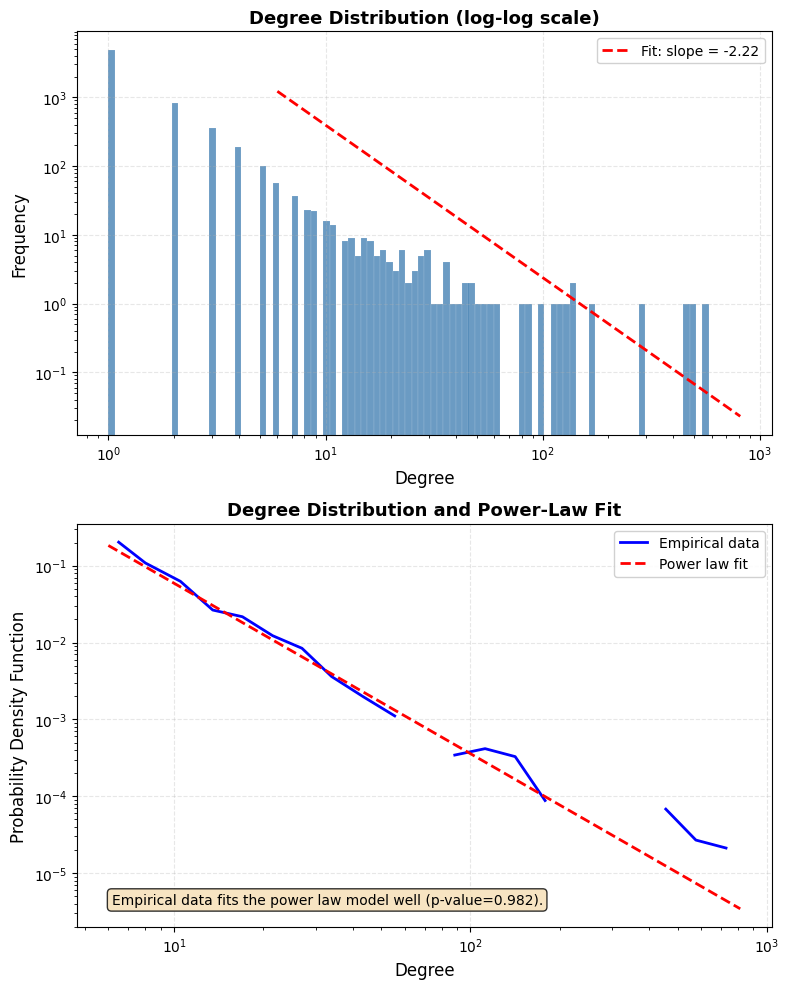

In [27]:
def plot_combined_powerlaw_analysis(degree_sequence, discrete=True):
    positive = [x for x in degree_sequence if x > 0]
    fit = powerlaw.Fit(positive, discrete=discrete)

    # Histogram bins
    unique_vals, counts = np.unique(positive, return_counts=True)
    mask = counts > 0
    unique_vals = unique_vals[mask]
    counts = counts[mask]

    slope = -fit.power_law.alpha
    res_p = compute_power_law_p_val(fit)

    # Stacked vertically: 2 rows, 1 column
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10))

    # TOP PANEL: log-log histogram with fit line

    # Log-spaced bins
    n_bins = 100  # fewer = thicker bars; try 10-20
    bin_edges = np.logspace(np.log10(min(positive)),
                            np.log10(max(positive)),
                            n_bins + 1)

    # Count values in each bin
    bin_counts, _ = np.histogram(positive, bins=bin_edges)

    # Bin centers (geometric mean of edges, since we're on log scale)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

    # Bar widths = edge-to-edge distance
    bin_widths = bin_edges[1:] - bin_edges[:-1]

    # Keep only non-empty bins
    mask = bin_counts > 0
    bin_centers = bin_centers[mask]
    bin_counts = bin_counts[mask]
    bin_widths = bin_widths[mask]

    ax1.bar(bin_centers, bin_counts, width=bin_widths,
            color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.1)
    
    x_fit = np.logspace(np.log10(fit.power_law.xmin),
                        np.log10(max(unique_vals)), 50)
    y_fit = fit.power_law.pdf(x_fit) * len(positive)
    ax1.plot(x_fit, y_fit, 'r--', linewidth=2, label=f'Fit: slope = {slope:.2f}')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Degree', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Degree Distribution (log-log scale)', fontsize=13, fontweight='bold')
    ax1.legend(loc='upper right', framealpha=0.9)
    ax1.grid(True, alpha=0.3, linestyle='--')

    # BOTTOM PANEL: PDF with empirical and fit
    fit.plot_pdf(label='Empirical data', color='blue', linewidth=2, ax=ax2)
    fit.power_law.plot_pdf(label='Power law fit', color='red',
                           linestyle='--', linewidth=2, ax=ax2)
    ax2.set_xlabel('Degree', fontsize=12)
    ax2.set_ylabel('Probability Density Function', fontsize=12)
    ax2.set_title('Degree Distribution and Power-Law Fit', fontsize=13, fontweight='bold')
    ax2.legend(loc='upper right', framealpha=0.9)
    ax2.grid(True, alpha=0.3, linestyle='--')

    if res_p < 0.1:
        interpretation = f"Empirical data does not fit the power law model well (p-value={res_p:.3f})."
    else:
        interpretation = f"Empirical data fits the power law model well (p-value={res_p:.3f})."
    ax2.text(0.05, 0.05, interpretation, transform=ax2.transAxes,
             fontsize=10, verticalalignment='bottom',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    return fig

dis = all(x == int(x) for x in degree_sequence)
fig = plot_combined_powerlaw_analysis(degree_sequence, discrete=dis)
fig.savefig('powerlaw_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## Parking Lot of Ideas

Not sure what to do with these:

In [ ]:
# Null hypothesis test for scale-free network
# H0: The degree distribution follows a power-law
# H1: The degree distribution does not follow a power-law

#Reusing the degree_sequence from above
# fit = powerlaw.Fit(degree_sequence)

# #KS statistic (distance between the distribution and the data)
# ks_statistic= fit.power_law.KS()

# # p-value comes from the fit object as well
# p_value= fit.power_law.D #fit stores KS distance as D

# print("KS Test results:")
# print(f"KS statistic (D)= {ks_statistic:.4f}")
# print(f"p-value= {fit.distribution_compare('power_law','exponential')[1]:.4f}")